# Appendix figure — `nn_ising_kappa_C` (nearest-neighbor Ising: κ vs C)

Reproduces the full `nn_ising_kappa_C.pdf` (Appendix C), **panels a–e**:

- **a–d** — per-energy-level reversed D_KL(q̂_{τ=1}‖p_T) and its τ-derivative at τ=1, for a low-T
  (T=2.3) and a high-T (T=4.0) single experiment (M=54, 4×4). Positive derivative ⇒ lower τ;
  negative ⇒ raise τ. From the committed `hld_dict_for_last_figs.jld2`.
- **e** — C(τ=1) and κ(τ=1) vs ground-truth T at M=54, recomputed from the fitted 4×4 models
  (κ>C at low T ⇒ lower τ; C>κ at high T ⇒ raise τ)

> Panels a–d run from the committed dict alone. **Panel e also requires the 4×4 Ising sweeps in
> `data/ising_sweeps/constant_M_4by4/`** (see the README "Data availability" section) and loads the


In [1]:
using DrWatson
@quickactivate "temp-tune"

# Panel e recomputes capacities from the fitted 4x4 models, so this notebook loads the full
# Ising src (heavier: Flux/SpinModels/etc.). Panels a–d need only the committed dict.
using JLD2, PyPlot, Statistics, Printf, StatsBase, Parameters, Flux, Graphs, SpinModels, Random, Distributions, LinearAlgebra

include(srcdir("matplotlib_helpers.jl"))     # set_size_for_paper, setup_notebook_for_paper, using_Py
include(srcdir("nearest_neighbor_ising.jl"))  # ExactMLBuffer, energy2spin, init_2dNN, get_level_index_dict

setup_notebook_for_paper()
using_Py(true)

In [9]:
# ===== nn_ising_kappa_C helpers =====

"Panels a–d: per-energy-level reversed D_KL(q̂_{τ=1}‖p_T) and its τ-derivative, low- and high-T."
function plot_dkl_et_al(ax, hld)
    lvl_resort = hld[:low][:lvl_resort]
    xx = collect(0:length(lvl_resort) - 1)
    iiddxxx = 2:10
    ax[1].bar(xx[iiddxxx], hld[:low][:dkl_q_p_per_lev][iiddxxx],        color="k")
    ax[2].bar(xx[iiddxxx], hld[:low][:DdklDtau_q_p_per_level][iiddxxx], color="k")
    ax[3].bar(xx[iiddxxx], hld[:high][:dkl_q_p_per_lev][iiddxxx],       color="k")
    ax[4].bar(xx[iiddxxx], hld[:high][:DdklDtau_q_p_per_level][iiddxxx], color="k")
    ax[1].set_ylabel(L"D_{KL}(\hat{q}_{\tau=1} || p_T)" * "\nper energy level")
    ax[2].set_ylabel(L"\frac{\partial}{\partial\tau} \left[D_{KL}(\hat{q}_{\tau} || p_T)\right]_{\tau=1}" * "\nper energy level")
    ax[2].set_xticks(xx[iiddxxx])
    ax[1].set_title("low T experiment", fontsize=8)
    ax[3].set_title("high T experiment", fontsize=8)
    ax[2].set_xlabel("energy level index")
    ax[4].set_xlabel("energy level index")
    ax[4].set_ylim(-0.45, 0.8)
    ax[3].set_ylim(-0.02, 0.35)
    ax[1].sharey(ax[3]); ax[2].sharey(ax[4])
    ax[3].tick_params(axis="y", labelleft=false)
    ax[4].tick_params(axis="y", labelleft=false)
    return nothing
end

# --- Panel e: C(τ=1), κ(τ=1) vs ground-truth T, recomputed from the fitted 4x4 models ---

"Per-state heat capacity C(τ) of the model with couplings `Jij` at temperature `temp`."
function get_heat_cap_per_state(Jij, temp, mlb, probs_container)
    (; all_states, all_states_energy, Z, exp_neg_energies) = mlb
    all_states_energy .= energy2spin(all_states, Jij)
    exp_neg_energies .= exp.(-all_states_energy ./ temp)
    sum!(Z, exp_neg_energies)
    probs_container .= exp_neg_energies ./ Z
    E_mean = sum(probs_container .* all_states_energy)
    ΔE² = (all_states_energy .- E_mean) .^ 2
    return (probs_container .* ΔE²) / (temp^2)
end

"Per-state cross-capacity κ: Cov_{q̂}(E_true/T, Ê) contribution."
function get_cross_cap_per_state(Jij_true, temp, Jfit, tau, mlb, q_container)
    q = q_container
    (; all_states, all_states_energy, Z, exp_neg_energies) = mlb
    all_states_energy .= energy2spin(all_states, Jfit)
    exp_neg_energies .= exp.(-all_states_energy ./ tau)
    sum!(Z, exp_neg_energies)
    q .= exp_neg_energies ./ Z
    E_fit_mean = sum(q .* all_states_energy)
    ΔE_fit = (all_states_energy .- E_fit_mean)
    E_true_over_T = energy2spin(all_states, Jij_true) ./ temp
    E_true_over_T_mean = sum(q .* E_true_over_T)
    ΔE_true = (E_true_over_T .- E_true_over_T_mean)
    return (q .* ΔE_fit .* ΔE_true) / tau
end

"Load fitted coupling matrices for all replicates at (M, T) from a constant-M sweep directory.
Exact T match (avoids `T=2.3` also grabbing `T=2.35`); pulls the fitted Ĵ out of `fit_model`."
function load_Jfits_at_M(dirs, M, T)
    pat = "_T=$(string(Float64(T)))_nsamps=$(string(Float64(M)))_"
    Jfits = Matrix{Float64}[]
    for dir in dirs, f in readdir(dir)
        occursin(pat, f) || continue
        d = JLD2.load(joinpath(dir, f))
        tk = first(k for k in keys(d) if startswith(k, "T="))
        fm = d[tk][:fit_model]
        Jkey = first(k for k in keys(fm) if fm[k] isa AbstractMatrix && size(fm[k]) == (16, 16))
        push!(Jfits, Matrix{Float64}(fm[Jkey]))
    end
    return Jfits
end

"Panel e plot: C(τ=1) and κ(τ=1) vs ground-truth T (globals `all_Tttt`, `Cmeans`, `kappameans`)."
function nn_C_kappa_plot(ax)
    ax.plot(all_Tttt, Cmeans, "k.", mfc="white", markeredgewidth=0.6,
            label=L"C(\tau=1) =\text{Var} (\hat E)_{\hat{q}_{\tau=1} }")
    ax.plot(all_Tttt, kappameans, color="k", markeredgewidth=0.6, marker=".", lw=0,
            label=L"\kappa(\tau=1) =\text{Cov} (\frac{E_\text{true}}{T}, \hat E)_{\hat{q}_{\tau=1} }")
    handless, labelss = ax.get_legend_handles_labels()
    ax.legend(labels=[labelss[2], labelss[1]], handles=[handless[2], handless[1]],
              handletextpad=0.0, labelspacing=0.1)
    ylimcurr = ax.get_ylim()
    ax.vlines(3.2, 0, 14, color="k", alpha=0.2)
    ax.set_ylim(ylimcurr)
    ax.set_xlabel("ground truth " * L"T")
    ax.set_ylabel("a.u.")
    return nothing
end

nn_C_kappa_plot

In [11]:
# Panels a–d: committed single-experiment dict (low-T T=2.3, high-T T=4.0, M=54).
hld = jldopen(f -> f["data"], joinpath(@__DIR__, "hld_dict_for_last_figs.jld2"), "r")

# Panel e: recompute C(τ=1) and κ(τ=1) vs ground-truth T at M=54 from the fitted 4×4 models.
# Needs the Ising sweeps in data/ising_sweeps/constant_M_4by4 (see README "Data availability").
dirs4 = [datadir("ising_sweeps", d) for d in ("constant_M_4by4", "constant_M_4by4_3")]
θ0, Jij_true = init_2dNN(4, 4)
mlb = ExactMLBuffer(Jij_true)

Tstrs = String[]
for dir in dirs4, f in readdir(dir)
    m = match(r"_T=([0-9.]+)_nsamps=54\.0_", f)
    m !== nothing && push!(Tstrs, m.captures[1])
end
all_Tttt = sort(unique(parse.(Float64, Tstrs)))

nstate = size(mlb.all_states, 2)
pcont = zeros(nstate); qcont = zeros(nstate)
Cmeans = Float64[]; kappameans = Float64[]
for T in all_Tttt
    jfs = load_Jfits_at_M(dirs4, 54, T)
    push!(Cmeans,     mean(sum(get_heat_cap_per_state(J, 1.0, mlb, pcont))              for J in jfs))
    push!(kappameans, mean(sum(get_cross_cap_per_state(Jij_true, T, J, 1.0, mlb, qcont)) for J in jfs))
end

@show hld[:low][:temp] hld[:high][:temp] length(all_Tttt);

(hld[:low])[:temp] = 2.3
(hld[:high])[:temp] = 4.0
length(all_Tttt) = 34


In [12]:
set_plot_style_for_paper()

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



saved reproduced nn_ising_kappa_C (a–e) to: /Users/pfields/Git/temp-tune/plots/supplemental/nn_ising_kappa_C_reproduced.svg


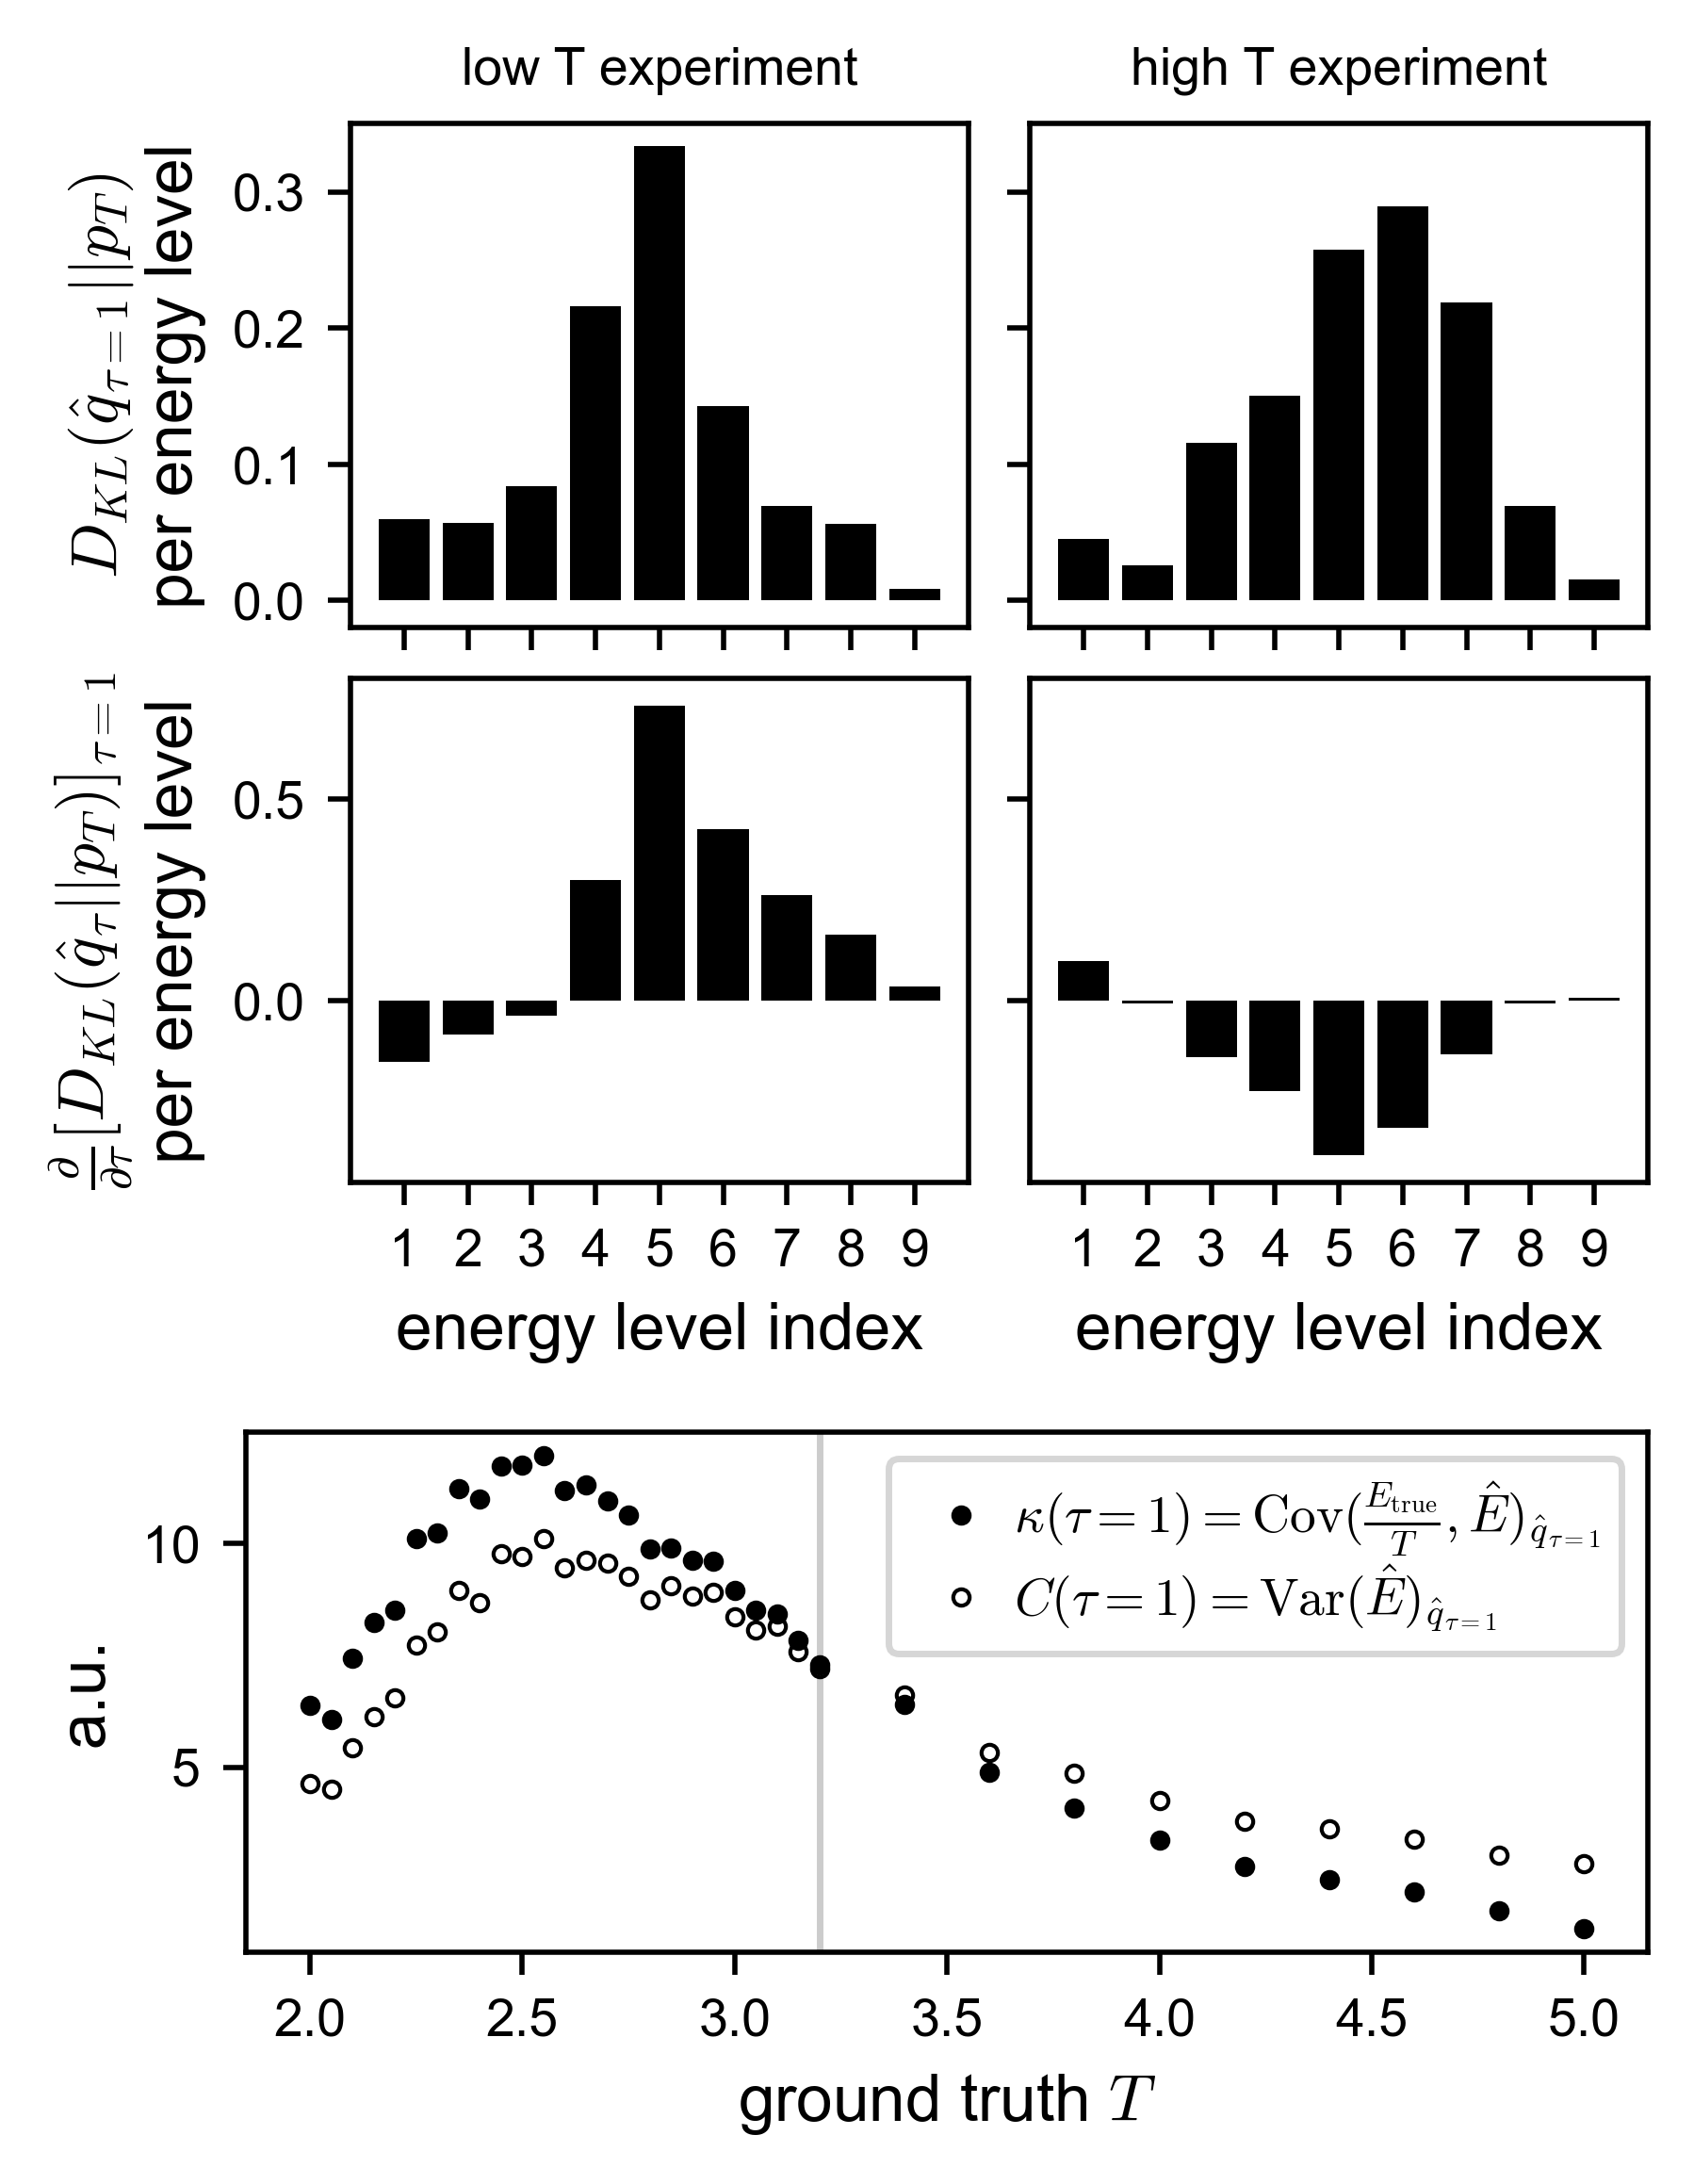

In [13]:
# Reproduce the full appendix figure `nn_ising_kappa_C.pdf` (panels a–e).
fig = plt.figure(figsize=set_size_for_paper(1, 1.2), dpi=500)
gs_main   = fig.add_gridspec(2, 2, left=0.19, right=0.999, bottom=0.45, top=1.0, hspace=0.1, wspace=0.1)
gs_bottom = fig.add_gridspec(1, 1, left=0.125, right=0.999, bottom=0.05, top=0.32)
ax1 = fig.add_subplot(gs_main[1, 1]); ax2 = fig.add_subplot(gs_main[0, 1])
ax3 = fig.add_subplot(gs_main[1, 0]); ax4 = fig.add_subplot(gs_main[0, 0])
ax5 = fig.add_subplot(gs_bottom[0, 0])
axs_top = [ax1, ax2, ax3, ax4]
ax1.sharex(ax2); ax3.sharex(ax2); ax4.sharex(ax2)
ax1.tick_params(labelbottom=false); ax3.tick_params(labelbottom=false)

plot_dkl_et_al(axs_top, hld)   # panels a–d (per-level reversed D_KL + τ-derivative, low/high T)
nn_C_kappa_plot(ax5)           # panel e (C, κ vs ground-truth T)

mkpath(plotsdir("supplemental"))
outpath = plotsdir("supplemental", "nn_ising_kappa_C_reproduced.svg")
savefig(outpath, bbox_inches="tight")
println("saved reproduced nn_ising_kappa_C (a–e) to: ", outpath)
# fig


